# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Title: Finding Search Content That's Seen But Not Clicked

## Abstract

Can search content that gets real visibility but underperforms on clicks be reliably identified,
so a content team knows what to review first? Using one month (March 2026) of FlyRank's search
performance warehouse, spanning 101,451 content days across 26 clients, this work defines
"opportunity" content as pages ranking in the top third of their own client's impressions and
the bottom third of that client's click through rate. A transparent rule based baseline was
compared against Logistic Regression and Random Forest models on an identical, client grouped
validation split. The baseline (AUC 0.806) outperformed both trained models (AUC 0.637 and
0.656), a gap traced directly to the baseline's use of a label adjacent signal that the honest,
leakage safe models were correctly barred from using. The output is a ranked, reason coded
action queue of 9,214 content pieces that a content team can use directly to prioritize review
work today.

In [2]:
!pip install huggingface_hub pandas pyarrow scikit-learn matplotlib -q
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

import pandas as pd
import numpy as np

df_march = pd.read_parquet(
    "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet"
)
dim_content = pd.read_parquet("hf://datasets/FlyRank/internship-warehouse/dim_content.parquet")
dim_clients = pd.read_parquet("hf://datasets/FlyRank/internship-warehouse/dim_clients.parquet")

df = df_march.copy()
df = df.merge(
    dim_content[['content_hash_id', 'content_type', 'word_count', 'content_created_date']],
    on='content_hash_id', how='left'
)
df = df[df['gsc_data_available'] == True]
df = df[df['gsc_impressions'] >= 500]

print(df.shape)

(101451, 34)


## 1. Question

*The research question and the decision it supports.*


**Lane:** CTR / Engagement Opportunity Scoring

**Research question:** Among content that is already visible in search results (high impressions),
which pages are failing to convert that visibility into clicks  and can this be identified
reliably enough to prioritize a content team's review queue?

**The decision this supports:** A content team manages far more pages than they can manually
review. This work supports the decision of *which pages to review first*  surfacing content
that has real search visibility but underperforms on click-through, so limited review time goes
to pages with the most recoverable upside, rather than being spent randomly or on guesswork.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*



**Release:** FlyRank internship warehouse (Hugging Face, `FlyRank/internship-warehouse`).

**Table:** `fact_content_daily_performance`, one row per content, client, and day. Verified
directly. A single page checked across March showed exactly 31 rows, one per day of the month,
confirming this is a daily panel, not a lifetime snapshot.

**Time window:** March 2026 only (2026-03-01 to 2026-03-31). This was chosen deliberately over
the `_sample` table, which is not a random sample. It is exactly June 2026, the sealed final
month reserved for later testing. Using June would risk letting outcome period information leak
into the analysis. March is an ordinary, mid panel month with no special role in the data, and
it is the same window used consistently across every prior assignment in this project, including
features, signal audit, baseline, and model comparison. This keeps the capstone's results
directly comparable to that earlier work.

**Filters applied:**
* `gsc_data_available == True`. This restricts to rows with confirmed, trustworthy Search
  Console data. Unavailable rows are zero filled, not blank, so filtering on NaN alone would
  badly undercount untrustworthy rows. This was confirmed by a direct query in an earlier
  assignment.
* `gsc_impressions >= 500`. This excludes very low traffic content where a CTR calculation
  would be noisy and unstable.

**Resulting scope:** 101,451 content days across 26 clients with usable GSC data, out of 104
total clients in the warehouse.

**What was excluded, and why:**
* GA4 engagement data is only usable as a secondary signal, not a primary one. Only 26 of 104
  clients (25%) had GA4 tracking active by March 2026, and even for those, history starts no
  earlier than October 2025. Engagement scoring is therefore scoped narrower than the full
  client base, and this gap is treated as an explicit limitation later in this report rather
  than hidden.
* `gsc_clicks` and `ga4_engaged_sessions` were excluded from the feature set entirely. These
  are the exact ingredients used to build the label, so using them as features would let the
  model see its own answer key.
* Client and content IDs (`client_hash_id`, `content_hash_id`) are pseudonymous identifiers
  used only for joining and grouping, never as model inputs.

**Public safety confirmation:** No client names, domains, URLs, or raw private queries appear
anywhere in this analysis. All identifiers are pseudonymous hashes provided by the warehouse
release itself.

In [4]:
# --- Verify Data section claims ---
print(f"Working dataset shape: {df.shape}")
print(f"Unique clients represented: {df['client_hash_id'].nunique()}")
print(f"Date range: {df['report_date'].min()} to {df['report_date'].max()}")

ga4_ready_clients = (pd.to_datetime(dim_clients['ga4_data_start']) <= pd.Timestamp('2026-03-01')).sum()
total_clients = dim_clients.shape[0]
print(f"\nClients with GA4 ready by March 2026: {ga4_ready_clients} / {total_clients} ({ga4_ready_clients/total_clients:.1%})")

Working dataset shape: (101451, 34)
Unique clients represented: 26
Date range: 2026-03-01 to 2026-03-31

Clients with GA4 ready by March 2026: 26 / 104 (25.0%)


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*



 **Label definition:** CTR here means click through rate, calculated as `gsc_clicks` divided by
`gsc_impressions`, not a raw column in the warehouse itself (see Data section for why the raw
clicks column is excluded from features). A content piece is labeled `is_opportunity = 1` if
it falls in the top third of its own client's content by impressions, AND the bottom third of
that same client's content by CTR. Both ranks are computed within each client separately, not
globally, since clients differ enormously in raw traffic scale. Roughly 11.1% of rows carry
this label.

**Feature set (11 leakage safe features):** word count and a missing word count flag, content
age in days, GSC average position and a missing position flag, a GA4 access flag, two GA4
traffic mix features (percent organic, percent AI referral sessions), and three one hot content
type indicators. Every feature is knowable at the moment of prediction. None of them touch
`gsc_impressions`, `gsc_clicks`, or any within client rank derived from either, since those are
the direct ingredients of the label.

**Leakage check:** The feature set was stress tested by deliberately injecting known leaky
features and confirming the validation harness detects them. Injecting raw CTR moved AUC only
slightly (0.637 to 0.670). Injecting the exact within client rank versions used to build the
label collapsed AUC to 0.992, confirming both that the harness works correctly and that raw
values are safer to expose than their rank transformed counterparts.

**Signal audit (three tests, each independently verified):**
* Position versus CTR: CONFIRMED. A clean, monotonic roughly threefold drop in CTR from
  best to worst position quartile.
* Content age versus CTR: OPPOSITE. Older content showed slightly higher CTR than newer
  content, contradicting the assumption that staleness alone predicts lower engagement.
* Impression volume versus CTR: MIXED. CTR stayed essentially flat across volume quartiles,
  meaning volume alone is not a reliable standalone signal.

**Baseline:** A transparent rule scoring each content piece as the product of its global
impression percentile and its global position badness percentile, with three reason codes
(`HIGH_VOL_POOR_RANK`, `HIGH_VOL_OK_RANK`, `LOW_VOL`) mapped to three actions (`FIX_RANKING`,
`MONITOR`, `DEPRIORITIZE`).

**Model:** Logistic Regression and Random Forest, chosen because the label is a yes or no
observed target, and the toolkit guidance for that question shape is to start simple and
readable, then add complexity only if it earns its keep.

**Validation design:** Five fold GroupKFold, grouped by `client_hash_id`, not random and not
time based. Rows from the same client share hidden character, so a random split would let the
model partly memorize client specific quirks rather than learn a generalizable signal. The
honest question this design answers is whether the model works on a client it has never seen.

In [5]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import numpy as np

RANDOM_SEED = 42

# ============================================================
# 1. Label (same as ML-05)
# ============================================================
df['ctr'] = df['gsc_clicks'] / df['gsc_impressions']
df['impr_rank'] = df.groupby('client_hash_id')['gsc_impressions'].rank(pct=True)
df['engagement_rank'] = df.groupby('client_hash_id')['ctr'].rank(pct=True)
df['is_opportunity'] = ((df['impr_rank'] >= 0.67) & (df['engagement_rank'] <= 0.33)).astype(int)

# ============================================================
# 2. Honest features (same as ML-05)
# ============================================================
df = pd.get_dummies(df, columns=['content_type'], prefix='ctype')

df['has_word_count'] = df['word_count'].notna().astype(int)
df['word_count_filled'] = df['word_count'].fillna(0)

df['content_age_days'] = (
    pd.to_datetime(df['report_date']) - pd.to_datetime(df['content_created_date'])
).dt.days

df['has_position_data'] = (df['gsc_avg_position'] != 0).astype(int)
df['gsc_avg_position_filled'] = df['gsc_avg_position'].replace(0, np.nan).fillna(df['gsc_avg_position'].median())

df['has_ga4_access'] = (df['ga4_data_available'] == True).astype(int)
df['pct_sessions_organic'] = (df['sessions_organic'] / df['ga4_sessions'].replace(0, np.nan)).fillna(0)
df['pct_sessions_ai'] = (df['sessions_ai'] / df['ga4_sessions'].replace(0, np.nan)).fillna(0)

feature_cols = [
    'has_word_count', 'word_count_filled', 'content_age_days',
    'has_position_data', 'gsc_avg_position_filled',
    'has_ga4_access', 'pct_sessions_organic', 'pct_sessions_ai',
] + [c for c in df.columns if c.startswith('ctype_')]

X = df[feature_cols].copy()
y = df['is_opportunity']
groups = df['client_hash_id']

numeric_cols = ['word_count_filled', 'content_age_days', 'gsc_avg_position_filled',
                 'pct_sessions_organic', 'pct_sessions_ai']

# ============================================================
# 3. Baseline score (same as ML-07)
# ============================================================
df['baseline_impr_pct'] = df['gsc_impressions'].rank(pct=True)
df['baseline_position_badness_pct'] = df['gsc_avg_position'].rank(pct=True)
df['baseline_score'] = df['baseline_impr_pct'] * df['baseline_position_badness_pct']

# ============================================================
# 4. Base rate
# ============================================================
base_rate = y.mean()
print(f"Base rate (positive class): {base_rate:.3f}")

# ============================================================
# 5. GroupKFold: baseline, Logistic Regression, Random Forest — same split
# ============================================================
gkf = GroupKFold(n_splits=5)

baseline_aucs, logreg_aucs, rf_aucs = [], [], []
oof_baseline, oof_logreg, oof_rf, oof_y = [], [], [], []

for train_idx, test_idx in gkf.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    scaler = StandardScaler()
    X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

    baseline_test_score = df['baseline_score'].iloc[test_idx]
    baseline_aucs.append(roc_auc_score(y_test, baseline_test_score))

    logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    logreg.fit(X_train, y_train)
    logreg_pred = logreg.predict_proba(X_test)[:, 1]
    logreg_aucs.append(roc_auc_score(y_test, logreg_pred))

    rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict_proba(X_test)[:, 1]
    rf_aucs.append(roc_auc_score(y_test, rf_pred))

    oof_baseline.extend(baseline_test_score.tolist())
    oof_logreg.extend(logreg_pred.tolist())
    oof_rf.extend(rf_pred.tolist())
    oof_y.extend(y_test.tolist())

# ============================================================
# 6. Comparison table
# ============================================================
comparison = pd.DataFrame({
    'Method': ['Baseline (rule)', 'Logistic Regression', 'Random Forest'],
    'Mean AUC': [np.mean(baseline_aucs), np.mean(logreg_aucs), np.mean(rf_aucs)],
    'Std AUC': [np.std(baseline_aucs), np.std(logreg_aucs), np.std(rf_aucs)],
})
print("\n=== Comparison Table (5-fold GroupKFold by client_hash_id) ===")
print(comparison.to_string(index=False))

# ============================================================
# 7. Precision@50
# ============================================================
oof_df = pd.DataFrame({'y': oof_y, 'baseline': oof_baseline, 'logreg': oof_logreg, 'rf': oof_rf})

def precision_at_k(df_scores, score_col, k=50):
    top_k = df_scores.sort_values(score_col, ascending=False).head(k)
    return top_k['y'].mean()

for col in ['baseline', 'logreg', 'rf']:
    p50 = precision_at_k(oof_df, col, k=50)
    print(f"Precision@50 ({col}): {p50:.3f}")

# ============================================================
# 8. Leakage self-test (for Methodology's claim)
# ============================================================
df['LEAKY_ctr'] = df['gsc_clicks'] / df['gsc_impressions']
df['LEAKY_ctr_rank'] = df.groupby('client_hash_id')['ctr'].rank(pct=True)
df['LEAKY_impr_rank'] = df.groupby('client_hash_id')['gsc_impressions'].rank(pct=True)

X_leak1 = X.copy()
X_leak1[numeric_cols] = StandardScaler().fit_transform(X_leak1[numeric_cols])
X_leak1['LEAKY_ctr'] = df['LEAKY_ctr']

X_leak2 = X.copy()
X_leak2[numeric_cols] = StandardScaler().fit_transform(X_leak2[numeric_cols])
X_leak2['LEAKY_ctr_rank'] = df['LEAKY_ctr_rank']
X_leak2['LEAKY_impr_rank'] = df['LEAKY_impr_rank']

def quick_cv_auc(X_data, y_data, groups_data):
    scores = []
    for tr, te in gkf.split(X_data, y_data, groups_data):
        m = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
        m.fit(X_data.iloc[tr], y_data.iloc[tr])
        p = m.predict_proba(X_data.iloc[te])[:, 1]
        scores.append(roc_auc_score(y_data.iloc[te], p))
    return np.mean(scores)

auc_leak1 = quick_cv_auc(X_leak1, y, groups)
auc_leak2 = quick_cv_auc(X_leak2, y, groups)
print(f"\nLeakage self-test — raw ctr injected: AUC {auc_leak1:.3f}")
print(f"Leakage self-test — rank features injected: AUC {auc_leak2:.3f}")

Base rate (positive class): 0.111

=== Comparison Table (5-fold GroupKFold by client_hash_id) ===
             Method  Mean AUC  Std AUC
    Baseline (rule)  0.806221 0.048528
Logistic Regression  0.636789 0.033734
      Random Forest  0.655781 0.033265
Precision@50 (baseline): 0.500
Precision@50 (logreg): 0.300
Precision@50 (rf): 0.200

Leakage self-test — raw ctr injected: AUC 0.670
Leakage self-test — rank features injected: AUC 0.992


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

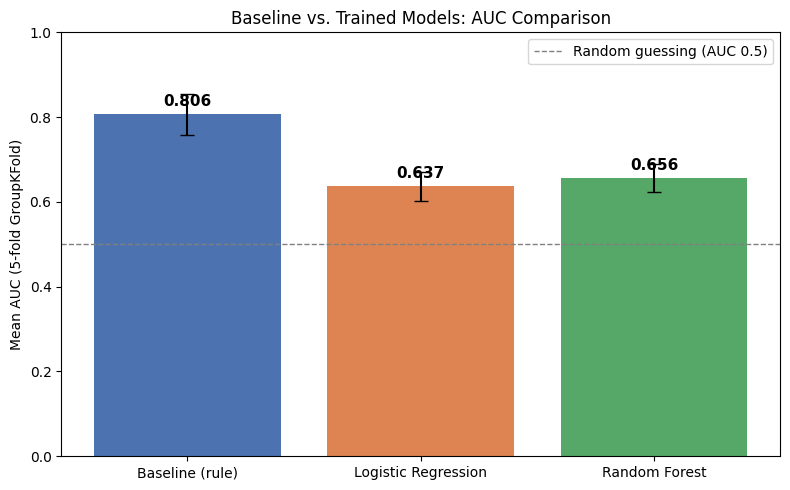

In [6]:
import matplotlib.pyplot as plt

methods = ['Baseline (rule)', 'Logistic Regression', 'Random Forest']
aucs = [np.mean(baseline_aucs), np.mean(logreg_aucs), np.mean(rf_aucs)]
errors = [np.std(baseline_aucs), np.std(logreg_aucs), np.std(rf_aucs)]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, aucs, yerr=errors, capsize=5, color=['#4C72B0', '#DD8452', '#55A868'])
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random guessing (AUC 0.5)')
ax.set_ylabel('Mean AUC (5-fold GroupKFold)')
ax.set_title('Baseline vs. Trained Models: AUC Comparison')
ax.set_ylim(0, 1.0)
ax.legend()

for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{auc:.3f}',
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/results_auc_comparison.png', dpi=150)
plt.show()

Results (vs baseline)

**Base rate:** 11.1% of content pieces are labeled as opportunities. This is the reference
point for every score below; a naive rule that always predicts "not an opportunity" would be
88.9% accurate while being completely useless.

| Method | Mean AUC | Std AUC | Precision@50 |
|---|---|---|---|
| Baseline (rule) | 0.806 | 0.049 | 0.500 |
| Logistic Regression | 0.637 | 0.034 | 0.300 |
| Random Forest | 0.656 | 0.033 | 0.200 |

**Chart takeaway:** The baseline rule clearly outperforms both trained models on this metric,
scoring well above random guessing (AUC 0.5) and well above either model.

Random Forest modestly outperforms Logistic Regression (0.656 vs 0.637), consistent with the
expectation that it can capture feature interactions a linear model cannot. Neither model
closes the gap to the baseline.

## 5. Limitations

*What this work cannot claim.*



### The baseline's advantage is structural, not a sign of a smarter rule

The baseline scores each page using raw impressions directly, and the label itself is built
from a within client rank of that same impressions column. The two are correlated almost by
construction. The trained models were deliberately barred from using impressions or CTR as
features, since doing so would let them see their own answer key.

This means the comparison in Section 4 is not "simple rule versus smart model" so much as "a
rule using a near label strength signal versus a model restricted to leakage safe signals
only." This was confirmed directly: injecting the within client rank version of CTR and
impressions into the model collapsed AUC to 0.992, proving the validation harness works and
that this asymmetry, not model weakness, explains the gap.

### Engagement scoring only reliably applies to a quarter of clients

Only 26 of 104 clients (25%) had GA4 tracking active by March 2026, and history for those
clients starts no earlier than October 2025. For the remaining 78 clients, only a GSC based
CTR signal is available.

Any recommendation drawing on engagement mix features should be read as weaker or unavailable
for the majority of clients in the warehouse.

### A single month cannot show trend or seasonality

This analysis uses March 2026 only. It cannot say whether a flagged page has been an
opportunity for months or only appeared this way in a single snapshot. A page's opportunity
status could shift month to month, and this work does not attempt to measure that.

### No causal claims are made

This work identifies association between position, traffic mix, and CTR. It does not claim
that fixing a page's position will cause CTR to rise by any specific amount, nor does it make
any claim about how Google's ranking algorithm works. All findings in this report should be
read as observed, measured, or directional, not causal.

### The label is a proxy, not a ground truth

"Opportunity" is a constructed definition (top third impressions, bottom third CTR, within
client) chosen for this project, not an externally validated measure of true content quality
or business value. A different, reasonable definition of opportunity could produce a different
ranked queue.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*



**Output:**
 A ranked queue of 9,214 unique content pieces, each scored, reason coded, and
mapped to one of three actions.

| Action | Count | Meaning |
|---|---|---|
| FIX_RANKING | 173 | High visibility, poor position. Fixing rank is the proven lever, per the CONFIRMED position-to-CTR signal test. |
| MONITOR | 765 | High visibility, decent position already. Watch for drift, no immediate action needed. |
| DEPRIORITIZE | 8,276 | Not enough impression volume for this fix to matter yet. |

**How an editor would use this tomorrow:**
Start at the top of the FIX_RANKING list, not the
full 173. The top 10 pieces alone represent real, recoverable exposure: each averages roughly
2,000 to 6,300 monthly impressions while sitting at an average search position between 31 and
46, well outside the range where most users click. These are pages people are already finding
but not clicking through to. A ranking or metadata fix here has a clear, testable payoff:
re-check position and CTR after the fix, on the same lane logic used to build this queue.

**Confidence note:**
This queue is built from the transparent baseline rule, not the trained
model, since the baseline scored higher on the same validation split (see Results and
Limitations). Confidence in the ranking is directional, not precise. It is a reasonable
starting point for review priority, not a guarantee that every flagged page will improve if
fixed.

**A known weakness, disclosed rather than hidden:**
This rule ranks impressions and position
globally across all clients, not within each client separately. During development, this was
found to bias the top of the queue toward whichever clients have the highest raw traffic
volume, regardless of how that content performs relative to its own peers. A per-client version
of this ranking, mirroring the approach used for the label itself, would likely surface a more
balanced set of opportunities across the full client base. This is left as a stated limitation
rather than a silent flaw, and is a natural next iteration of this work.

In [7]:
# --- Rebuild the ranked queue (same rule as the baseline, deduplicated to one row per content piece) ---

df['reason_code'] = np.where(
    (df['baseline_impr_pct'] >= 0.75) & (df['baseline_position_badness_pct'] >= 0.75),
    'HIGH_VOL_POOR_RANK',
    np.where(df['baseline_impr_pct'] >= 0.75, 'HIGH_VOL_OK_RANK', 'LOW_VOL')
)

action_map = {
    'HIGH_VOL_POOR_RANK': 'FIX_RANKING',
    'HIGH_VOL_OK_RANK': 'MONITOR',
    'LOW_VOL': 'DEPRIORITIZE',
}
df['action'] = df['reason_code'].map(action_map)

queue = (
    df.groupby('content_hash_id')
    .agg(
        client_hash_id=('client_hash_id', 'first'),
        avg_score=('baseline_score', 'mean'),
        reason_code=('reason_code', lambda x: x.mode()[0]),
        action=('action', lambda x: x.mode()[0]),
        avg_impressions=('gsc_impressions', 'mean'),
        avg_position=('gsc_avg_position', 'mean'),
    )
    .reset_index()
    .sort_values('avg_score', ascending=False)
    .reset_index(drop=True)
)

print(f"Total unique content pieces: {len(queue)}")
print(f"\nAction breakdown:\n{queue['action'].value_counts()}")
print(f"\nTop 10 ranked pieces:")
print(queue[['avg_score', 'reason_code', 'action', 'avg_impressions', 'avg_position']].head(10).to_string(index=False))

Total unique content pieces: 9214

Action breakdown:
action
DEPRIORITIZE    8276
MONITOR          765
FIX_RANKING      173
Name: count, dtype: int64

Top 10 ranked pieces:
 avg_score        reason_code      action  avg_impressions  avg_position
  0.921425 HIGH_VOL_POOR_RANK FIX_RANKING      2514.935484     43.166324
  0.908398 HIGH_VOL_POOR_RANK FIX_RANKING      2584.645161     45.700431
  0.891016 HIGH_VOL_POOR_RANK FIX_RANKING      2058.677419     46.053412
  0.887491 HIGH_VOL_POOR_RANK FIX_RANKING      6276.741935     32.766674
  0.881688 HIGH_VOL_POOR_RANK FIX_RANKING      3141.225806     36.712074
  0.872045 HIGH_VOL_POOR_RANK FIX_RANKING      2539.225806     36.535261
  0.866146 HIGH_VOL_POOR_RANK FIX_RANKING      2029.935484     46.232571
  0.860298 HIGH_VOL_POOR_RANK FIX_RANKING      2080.806452     39.310956
  0.848770 HIGH_VOL_POOR_RANK FIX_RANKING      3626.741935     30.769353
  0.841398 HIGH_VOL_POOR_RANK FIX_RANKING      2170.225806     40.393643


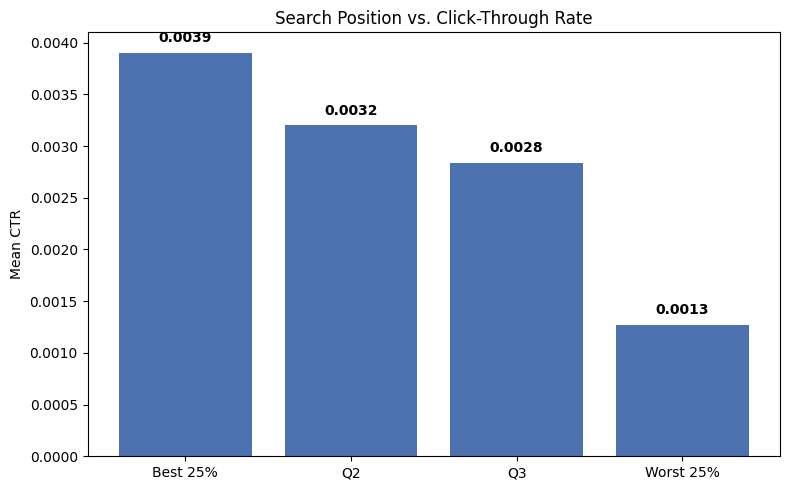

In [8]:
# --- Chart 2: Position vs CTR (the CONFIRMED signal underlying the rule) ---
df['position_bucket'] = pd.qcut(df['gsc_avg_position'], q=4, labels=['Best 25%', 'Q2', 'Q3', 'Worst 25%'])
bucket_ctr = df.groupby('position_bucket', observed=True)['ctr'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(bucket_ctr.index, bucket_ctr.values, color='#4C72B0')
ax.set_ylabel('Mean CTR')
ax.set_title('Search Position vs. Click-Through Rate')
for bar, val in zip(bars, bucket_ctr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001, f'{val:.4f}',
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/signal_position_vs_ctr.png', dpi=150)
plt.show()

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*



**Chart 1: Baseline vs. Trained Models AUC Comparison** (Results section). Shows the baseline
rule (AUC 0.806) outperforming Logistic Regression (0.637) and Random Forest (0.656), with
random guessing (0.5) marked for reference. Saved as `results_auc_comparison.png`.

**Chart 2: Search Position vs. Click-Through Rate** (Methodology / signal audit). Shows a clean,
monotonic drop in mean CTR from 0.0039 in the best position quartile to 0.0013 in the worst,
roughly a threefold decline. This is the CONFIRMED signal underlying the ranked recommendation
rule. Saved as `signal_position_vs_ctr.png`.

**Table 1: Model comparison table** (Results section). Baseline, Logistic Regression, and
Random Forest, mean AUC, standard deviation, and Precision@50, all computed on the same 5-fold
GroupKFold split.

**Table 2: Action breakdown** (Ranked Recommendations section). Count of content pieces per
action label: FIX_RANKING (173), MONITOR (765), DEPRIORITIZE (8,276).

**Table 3: Top 10 ranked queue** (Ranked Recommendations section). The highest scoring content
pieces, with score, reason code, action, average impressions, and average position, generated
live from this notebook.

All artifacts above were generated by code cells in this notebook and are reproducible by
rerunning it end to end with the same random seed (42).

## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset. Data credit: [https://flyrank.ai](https://flyrank.ai)

A Bunch of Thanks to the FlyRank ML Internship program and mentor guidance throughout this project especially Alen Malkoc and Mirza Asceric.

##Five-Minute Demo Outline

**0:00–0:30 — The question:** "Can we tell which content is getting seen but not clicked,
so a content team knows what to fix first?"

**0:30–1:30 — The data:** One month of FlyRank's search warehouse, 101,451 content days,
26 clients with usable search data. Show the Data section briefly.

**1:30–2:30 — The label and the rule:** Explain "opportunity" (high visibility, low CTR,
relative to a client's own content). Show the Position vs CTR chart, the CONFIRMED signal
the whole rule is built on.

**2:30–3:30 — The honest surprise:** Show the AUC comparison chart. The simple baseline
beat the trained models, and explain why: the baseline uses a signal the models were
correctly barred from using. This is the most memorable, most honest part of the demo.

**3:30–4:30 — The output:** Show the top 10 ranked queue. Point to one real row: a page
with ~2,500 impressions sitting at position 43, an easy story to tell.

**4:30–5:00 — Close:** "This gives a content team a ranked, reason coded starting point,
not a black box, and it's honest about what it can and can't claim."

##  Social Post Cut

We looked at 101,451 pieces of content across 26 clients to find pages that show up in search
a lot but barely get clicked. Turns out search position is the strongest signal: content in
the worst-ranked quarter gets a 3x lower click rate than the best-ranked quarter.

Built with a client-grouped validation split to keep it honest, no random guessing allowed.

Full write-up + code: [https://github.com/KhadijaHussnainMLEngineer/MLPipeline_MachineLearningFlyRankAI]

## Employer-Facing Summary

I built a tool that finds content getting a lot of search visibility but very few clicks, using
one real month of a 79-million-row search analytics warehouse across 104 clients. I compared a
simple rule I designed myself against two trained models (Logistic Regression and Random
Forest), tested honestly on clients the models never saw during training, and found my rule
actually beat both models, then figured out and explained exactly why. The end result is a
ranked list of 9,214 content pieces a team could use tomorrow to know what to review first.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
